In [19]:
import duckdb
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
temp_df = pd.read_excel('../cleaned_data/online_retail_II_cleaned.xlsx')
duckdb.sql("""
SELECT *
FROM temp_df
LIMIT 1
""").df()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom


In [ ]:
rfm_query = """
WITH cleaned_data AS (
    SELECT 
        "Customer ID" AS customer_id,
        Invoice AS invoice,
        CAST(InvoiceDate AS TIMESTAMP) AS invoice_date,
        (Quantity * Price) AS total_sum
    FROM temp_df
    WHERE "Customer ID" IS NOT NULL 
      AND Quantity > 0 
      AND Price > 0
      AND CAST(Invoice AS VARCHAR) NOT LIKE 'C%' -- Drops cancellations
)

SELECT
    customer_id,
    -- Recency: Days between customer's last order and the very last day in the dataset
    date_diff('day', MAX(invoice_date), (SELECT MAX(invoice_date) FROM cleaned_data)) AS recency,
    -- Frequency: Count of unique invoices (trips to the store)
    COUNT(DISTINCT invoice) AS frequency,
    -- Monetary: Total money spent
    SUM(total_sum) AS monetary
FROM cleaned_data
GROUP BY customer_id
"""
# Execute the query and store as a Pandas DataFrame for ML
rfm_df = duckdb.sql(rfm_query).df()

print("--- Step 1: Raw RFM Table ---")
print(rfm_df.head())
print(f"Total Unique Customers: {len(rfm_df)}")


--- Step 1: Raw RFM Table ---
   customer_id  recency  frequency  monetary
0      14285.0      148          4   1374.41
1      13881.0       10         23  28019.58
2      16392.0       48          2    541.86
3      13874.0      139          6   1508.70
4      13173.0        2         10   2285.70
Total Unique Customers: 4312


In [6]:
# ---------------------------------------------------------
# Phase 2: Machine Learning Preprocessing (Log Transformation)
# ---------------------------------------------------------
# Why? K-Means clustering uses 'Euclidean Distance' (straight lines). 
# If Monetary ranges from $10 to $100,000, it breaks the math. 
# Log transformation squashes massive outliers into a neat, normal distribution.

# We use np.log1p (which does log(x + 1)) to safely handle any potential zeros
rfm_log_df = rfm_df.copy()
rfm_log_df['recency_log'] = np.log1p(rfm_df['recency'])
rfm_log_df['frequency_log'] = np.log1p(rfm_df['frequency'])
rfm_log_df['monetary_log'] = np.log1p(rfm_df['monetary'])

print("\n--- Step 2: Log Transformed Data (Ready for Scaling) ---")
print(rfm_log_df[['customer_id', 'recency_log', 'frequency_log', 'monetary_log']].head())


--- Step 2: Log Transformed Data (Ready for Scaling) ---
   customer_id  recency_log  frequency_log  monetary_log
0      14285.0     5.003946       1.609438      7.226507
1      13881.0     2.397895       3.178054     10.240695
2      16392.0     3.891820       1.098612      6.296851
3      13874.0     4.941642       1.945910      7.319666
4      13173.0     1.098612       2.397895      7.734865


Running simulations to find the optimal K...


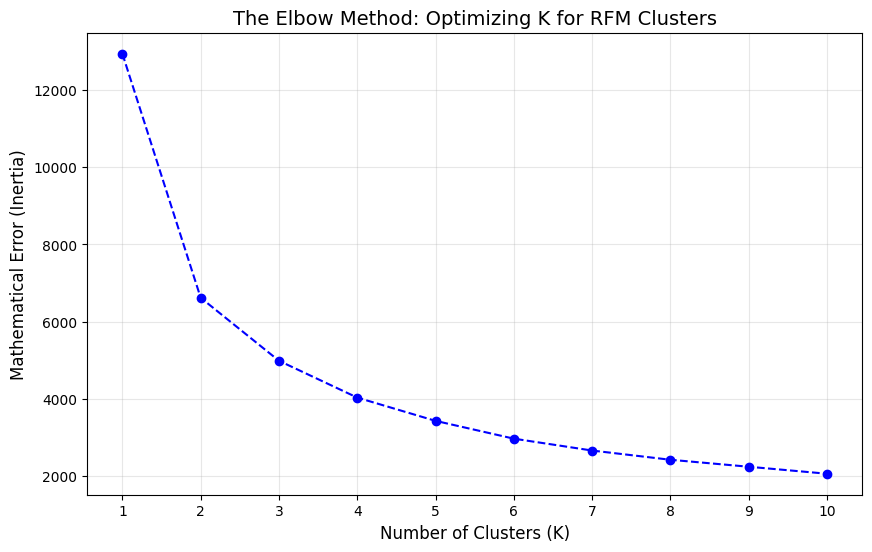

In [10]:
# 1. Isolate the features we want to feed the model
features = ['recency_log', 'frequency_log', 'monetary_log']
X = rfm_log_df[features]

# 2. Scale the data (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. The Elbow Method (Finding the Sweet Spot)
print("Running simulations to find the optimal K...")
inertia = []
k_range = range(1, 11)

for k in k_range:
    # random_state ensures reproducibility (everyone gets the same result)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    # Inertia is the mathematical measurement of 'Error' (Euclidean distance)
    inertia.append(kmeans.inertia_)

# 4. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method: Optimizing K for RFM Clusters', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Mathematical Error (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# 1. Train the final model with our chosen K (Adjust to 3 if your elbow is sharper at 3)
OPTIMAL_K = 4 
final_model = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(X_scaled)

# 2. The 'Systems Thinking' Merge: 
# Attach the AI's math labels back to the ORIGINAL human-readable business data
rfm_df['Cluster'] = cluster_labels

# 3. Calculate the Business Value of each cluster
cluster_summary = rfm_df.groupby('Cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'count']
}).round(1)

# Rename columns for presentation
cluster_summary.columns = ['Avg Recency (Days)', 'Avg Frequency (Trips)', 'Avg Spend (£)', 'Total Customers']
cluster_summary = cluster_summary.sort_values(by='Avg Spend (£)', ascending=False)

print("\n--- FINAL BUSINESS SEGMENTATION ---")
print(cluster_summary)


--- FINAL BUSINESS SEGMENTATION ---
         Avg Recency (Days)  Avg Frequency (Trips)  Avg Spend (£)  \
Cluster                                                             
1                      11.6                   14.1         7788.4   
2                      75.0                    4.3         1859.0   
0                      22.2                    2.0          540.7   
3                     184.5                    1.3          316.1   

         Total Customers  
Cluster                   
1                    713  
2                   1257  
0                    898  
3                   1444  


In [11]:
# Assuming X_scaled is still in your memory from the previous steps
print("Calculating Silhouette Scores... (This takes a few seconds)")

# Fit K=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(X_scaled)
sil_score_3 = silhouette_score(X_scaled, labels_3)

# Fit K=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(X_scaled)
sil_score_4 = silhouette_score(X_scaled, labels_4)

print(f"Mathematical Score for K=3: {sil_score_3:.4f}")
print(f"Mathematical Score for K=4: {sil_score_4:.4f}")
print("-" * 30)
if sil_score_4 >= sil_score_3:
    print("Result: K=4 is mathematically better AND provides better business value.")
elif (sil_score_3 - sil_score_4) < 0.05:
    print("Result: K=3 is slightly better mathematically, but K=4's business value likely justifies the tiny math penalty.")
else:
    print("Result: K=3 is significantly better mathematically. Forcing 4 clusters is creating artificial groups.")

Calculating Silhouette Scores... (This takes a few seconds)
Mathematical Score for K=3: 0.3303
Mathematical Score for K=4: 0.3287
------------------------------
Result: K=3 is slightly better mathematically, but K=4's business value likely justifies the tiny math penalty.


In [16]:
# Check the exact count of each segment
print("Before SMOTE:")
print(y.value_counts())

Before SMOTE:
Cluster
3    1444
2    1257
0     898
1     713
Name: count, dtype: int64


In [ ]:
# Split into Training and Testing Vaults FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Balancer
smote = SMOTE(random_state=42)

# Apply SMOTE *ONLY* to the Training Data (X_train and y_train)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Prove the Balancer Worked
print("--- AFTER SMOTE: Perfect AI Training Environment ---")
print(y_train_smote.value_counts())

--- AFTER SMOTE: Perfect AI Training Environment ---
Cluster
3    1162
2    1162
1    1162
0    1162
Name: count, dtype: int64


In [22]:
# Initialize the XGBoost Engine
# n_estimators = 100 trees, learning_rate = how aggressively it fixes mistakes
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the AI (Using ONLY the perfectly balanced SMOTE data)
xgb_model.fit(X_train_smote, y_train_smote)

# Predict the real, untouched test customers
# Open the vault and ask it to predict the real, untouched test customers
predictions = xgb_model.predict(X_test)

# 10. Evaluation Metrics
accuracy = accuracy_score(y_test, predictions)

print("\n--- VERSION 2.0 FINAL RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Diagnostic Report:")
print(classification_report(y_test, predictions))


--- VERSION 2.0 FINAL RESULTS ---
Overall Accuracy: 98.49%

Detailed Diagnostic Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       189
           1       0.99      0.97      0.98       139
           2       0.97      0.98      0.98       253
           3       0.99      0.99      0.99       282

    accuracy                           0.98       863
   macro avg       0.99      0.98      0.98       863
weighted avg       0.99      0.98      0.98       863

